<h1 style="color:#56B4E9;">Week 8 — Day 2</h1>

<h2 style="color:#0072B2;">Text Representation: TF-IDF and Word Embeddings</h2>

### IMDB Sentiment Analysis — Continuing the Day 1 Pipeline

Day 1 produced fixed training, validation, and test splits with two task-specific text versions. Day 2 begins by converting those cleaned texts into numeric representations that machine-learning models can process.

<h2 style="color:#0072B2;">Learning Objectives</h2>

In this notebook, we will gradually learn to:

- Convert cleaned reviews into numeric vectors.
- Understand Bag of Words and TF-IDF weighting.
- Prevent data leakage by fitting representations on training data only.
- Compare TF-IDF with word and contextual embeddings.
- Evaluate representations on the same IMDB splits used in Week 7.

<h2 style="color:#0072B2;">2.1 Loading the Day 1 Outputs</h2>

The preprocessing pipeline is not repeated here. The saved Day 1 files are loaded so that Day 2 uses the same reviews, labels, and text versions.

- `minimal_text` preserves most of the original linguistic structure.
- `classical_text` applies stronger cleaning for classical text models.

In [1]:
from pathlib import Path

import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

DATA_DIR = Path("../day1/outputs/week8_day1")

train_df = pd.read_csv(DATA_DIR / "imdb_train_preprocessed.csv")
validation_df = pd.read_csv(DATA_DIR / "imdb_validation_preprocessed.csv")
test_df = pd.read_csv(DATA_DIR / "imdb_test_preprocessed.csv")

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

Training shape: (4000, 5)
Validation shape: (1000, 5)
Test shape: (1000, 5)


<h3 style="color:#009E73;">Input Verification</h3>

Before vectorization, the three splits are checked for the expected sizes, required columns, missing text, and label balance. This confirms that Day 2 starts from the intended Day 1 outputs.

In [2]:
required_columns = {
    "text", "minimal_text", "classical_text", "label", "sentiment"
}

split_summary = pd.DataFrame([
    {
        "Split": name,
        "Rows": len(dataframe),
        "Negative": (dataframe["label"] == 0).sum(),
        "Positive": (dataframe["label"] == 1).sum(),
        "Missing minimal": dataframe["minimal_text"].isna().sum(),
        "Missing classical": dataframe["classical_text"].isna().sum(),
    }
    for name, dataframe in [
        ("Training", train_df),
        ("Validation", validation_df),
        ("Test", test_df),
    ]
])

display(split_summary)
assert [len(train_df), len(validation_df), len(test_df)] == [4000, 1000, 1000]
assert all(required_columns.issubset(df.columns) for df in [train_df, validation_df, test_df])

,Split,Rows,Negative,Positive,Missing minimal,Missing classical
0,Training,4000,1997,2003,0,0
1,Validation,1000,499,501,0,0
2,Test,1000,498,502,0,0


<h2 style="color:#0072B2;">2.2 From Text to Numbers</h2>

A model such as Logistic Regression cannot multiply weights by words. Each review must first be mapped to a numeric vector:

$$\text{review} \longrightarrow \mathbf{x} \in \mathbb{R}^{d}$$

The representation determines what information the model receives. A count-based representation records which vocabulary terms occur, while sequence models such as LSTM and DistilBERT preserve additional order or context information.

<h2 style="color:#0072B2;">2.3 Bag of Words</h2>

Bag of Words creates one column for each vocabulary term and one row for each review. Each cell stores the term count in that review.

For the vocabulary `[good, bad, movie]`, the review `good good movie` becomes `[2, 0, 1]`.

This representation is simple and interpretable, but it ignores word order. Bigrams can partly reduce this limitation by treating consecutive pairs such as `not good` as separate features.

In [3]:
example_reviews = [
    "good movie",
    "bad movie",
    "good good movie",
]

count_vectorizer = CountVectorizer()
count_matrix = count_vectorizer.fit_transform(example_reviews)

count_table = pd.DataFrame(
    count_matrix.toarray(),
    columns=count_vectorizer.get_feature_names_out(),
    index=["Review 1", "Review 2", "Review 3"],
)
display(count_table)

,bad,good,movie
Review 1,0,1,1
Review 2,1,0,1
Review 3,0,2,1


<h2 style="color:#0072B2;">2.4 TF-IDF Weighting</h2>

Raw counts treat every occurrence equally. TF-IDF gives more weight to terms that are frequent in one document but uncommon across the document collection.

$$\text{TF-IDF}(t,d)=\text{TF}(t,d)\times\text{IDF}(t)$$

Scikit-learn uses smoothed inverse document frequency:

$$\text{IDF}(t)=\ln\left(\frac{N+1}{\text{DF}(t)+1}\right)+1$$

Here, $N$ is the number of training documents and $\text{DF}(t)$ is the number of training documents containing term $t$. A term appearing in nearly every review receives less emphasis than a more distinctive term.

In [4]:
tfidf_vectorizer = TfidfVectorizer(norm=None)
tfidf_matrix = tfidf_vectorizer.fit_transform(example_reviews)

tfidf_table = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=["Review 1", "Review 2", "Review 3"],
).round(3)

display(tfidf_table)
print("Matrix shape:", tfidf_matrix.shape)
print("Stored non-zero values:", tfidf_matrix.nnz)

,bad,good,movie
Review 1,0.000,1.288,1.0
Review 2,1.693,0.000,1.0
Review 3,0.000,2.575,1.0


Matrix shape: (3, 3)
Stored non-zero values: 6


<h3 style="color:#009E73;">Fit, Transform, and Sparse Storage</h3>

`fit` learns the vocabulary and IDF values. `transform` applies that fixed representation to new reviews. In the real experiment, fitting must use training text only; validation and test text are transformed without changing the learned vocabulary.

The resulting matrix is sparse because each review uses only a small fraction of the full vocabulary. Sparse storage keeps only non-zero positions and values, reducing memory use.

<h3 style="color:#009E73;">Current Checkpoint</h3>

At this stage, the notebook only loads the Day 1 outputs and demonstrates the representations on a small controlled example. The full IMDB vectorization and model training will be added after studying and selecting the TF-IDF settings.

<h2 style="color:#0072B2;">2.5 TF-IDF Configuration Experiments</h2>

The TF-IDF settings will be selected using validation F1 only. Each experiment changes one important choice while keeping the classifier fixed.

The tested choices include:

- Minimal versus classical text.
- Unigrams versus unigrams and bigrams.
- Vocabulary size.
- Rare-term filtering.
- Common-term filtering.
- Sublinear term frequency.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

configurations = [
    {
        "Name": "Baseline",
        "Text column": "classical_text",
        "max_features": 5000,
        "min_df": 1,
        "max_df": 1.0,
        "ngram_range": (1, 1),
        "sublinear_tf": False,
    },
    {
        "Name": "Larger vocabulary",
        "Text column": "classical_text",
        "max_features": 10000,
        "min_df": 1,
        "max_df": 1.0,
        "ngram_range": (1, 1),
        "sublinear_tf": False,
    },
    {
        "Name": "Remove rare terms",
        "Text column": "classical_text",
        "max_features": 10000,
        "min_df": 2,
        "max_df": 1.0,
        "ngram_range": (1, 1),
        "sublinear_tf": False,
    },
    {
        "Name": "Remove very common terms",
        "Text column": "classical_text",
        "max_features": 10000,
        "min_df": 2,
        "max_df": 0.95,
        "ngram_range": (1, 1),
        "sublinear_tf": False,
    },
    {
        "Name": "Sublinear TF",
        "Text column": "classical_text",
        "max_features": 10000,
        "min_df": 2,
        "max_df": 0.95,
        "ngram_range": (1, 1),
        "sublinear_tf": True,
    },
    {
        "Name": "Add bigrams",
        "Text column": "classical_text",
        "max_features": 10000,
        "min_df": 2,
        "max_df": 0.95,
        "ngram_range": (1, 2),
        "sublinear_tf": True,
    },
    {
        "Name": "Minimal text with bigrams",
        "Text column": "minimal_text",
        "max_features": 10000,
        "min_df": 2,
        "max_df": 0.95,
        "ngram_range": (1, 2),
        "sublinear_tf": True,
    },
]

<h3 style="color:#009E73;">Training and Validation</h3>

For every configuration:

1. The vectorizer learns its vocabulary and IDF values from training text only.
2. Validation text is transformed using the fixed training vocabulary.
3. Logistic Regression is trained on the TF-IDF training matrix.
4. Validation F1 is calculated for model selection.

The test split remains untouched.

In [6]:
def evaluate_configuration(config):
    text_column = config["Text column"]

    vectorizer = TfidfVectorizer(
        max_features=config["max_features"],
        min_df=config["min_df"],
        max_df=config["max_df"],
        ngram_range=config["ngram_range"],
        sublinear_tf=config["sublinear_tf"],
    )

    X_train = vectorizer.fit_transform(train_df[text_column])
    X_validation = vectorizer.transform(validation_df[text_column])

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, train_df["label"])

    predictions = model.predict(X_validation)

    return {
        "Configuration": config["Name"],
        "Text version": text_column,
        "Features": X_train.shape[1],
        "Validation F1": f1_score(validation_df["label"], predictions),
    }, vectorizer, model

<h3 style="color:#009E73;">Comparing the Configurations</h3>

The experiments are ranked by validation F1. The trained vectorizers and models are retained so the best configuration can be inspected before final testing.

In [7]:
validation_results = []
trained_runs = {}

for config in configurations:
    result, vectorizer, model = evaluate_configuration(config)

    validation_results.append(result)
    trained_runs[config["Name"]] = {
        "vectorizer": vectorizer,
        "model": model,
        "config": config,
    }

validation_results_df = pd.DataFrame(validation_results)
validation_results_df = validation_results_df.sort_values(
    "Validation F1",
    ascending=False,
).reset_index(drop=True)

display(validation_results_df.round(4))

,Configuration,Text version,Features,Validation F1
0,Minimal text with bigrams,minimal_text,10000,0.8808
1,Add bigrams,classical_text,10000,0.8786
2,Sublinear TF,classical_text,10000,0.8755
3,Baseline,classical_text,5000,0.8616
4,Larger vocabulary,classical_text,10000,0.8566
5,Remove rare terms,classical_text,10000,0.8566
6,Remove very common terms,classical_text,10000,0.8566


In [8]:
best_configuration_name = validation_results_df.loc[0, "Configuration"]
best_validation_f1 = validation_results_df.loc[0, "Validation F1"]

print("Best configuration:", best_configuration_name)
print("Best validation F1:", round(best_validation_f1, 4))
print("Test data has not been used.")

Best configuration: Minimal text with bigrams
Best validation F1: 0.8808
Test data has not been used.


<h2 style="color:#0072B2;">2.6 Interpreting Logistic Regression Weights</h2>

Logistic Regression learns one coefficient for every TF-IDF feature.

- A large positive coefficient pushes the prediction toward positive sentiment.
- A large negative coefficient pushes the prediction toward negative sentiment.
- A coefficient near zero has little influence on the prediction.

Because the best representation includes bigrams, the features may be individual words or two-word phrases.

In [9]:
best_run = trained_runs[best_configuration_name]

best_vectorizer = best_run["vectorizer"]
best_model = best_run["model"]

feature_names = best_vectorizer.get_feature_names_out()
coefficients = best_model.coef_[0]

top_n = 15

negative_indices = coefficients.argsort()[:top_n]
positive_indices = coefficients.argsort()[-top_n:][::-1]

negative_terms_df = pd.DataFrame({
    "Negative term": feature_names[negative_indices],
    "Coefficient": coefficients[negative_indices],
})

positive_terms_df = pd.DataFrame({
    "Positive term": feature_names[positive_indices],
    "Coefficient": coefficients[positive_indices],
})

display(negative_terms_df.round(4))
display(positive_terms_df.round(4))

,Negative term,Coefficient
0,bad,-3.5920
1,worst,-3.5411
2,the worst,-2.8579
3,poor,-2.7642
4,nothing,-2.4134
5,plot,-2.2247
6,waste,-2.2084
7,no,-2.1990
8,boring,-2.1495
9,awful,-2.1332


,Positive term,Coefficient
0,great,3.2800
1,the best,2.3381
2,excellent,2.2324
3,best,2.0952
4,wonderful,2.0466
5,also,1.8901
6,love,1.8688
7,it is,1.6907
8,perfect,1.6856
9,very,1.5574


<h3 style="color:#009E73;">Visualizing the Strongest Terms</h3>

The chart shows which words and bigrams have the strongest influence on the model. The coefficients describe learned statistical associations, not universal meanings.

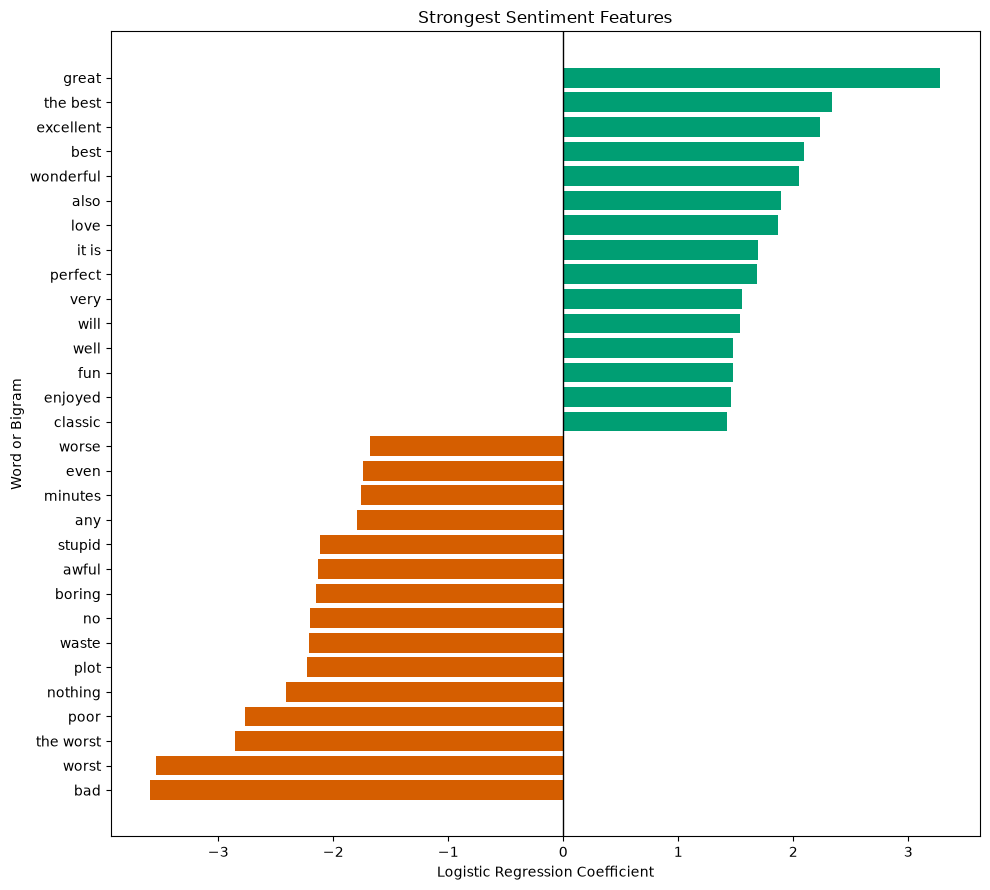

In [10]:
import matplotlib.pyplot as plt

important_terms = pd.concat([
    pd.DataFrame({
        "Term": feature_names[negative_indices],
        "Coefficient": coefficients[negative_indices],
        "Sentiment": "Negative",
    }),
    pd.DataFrame({
        "Term": feature_names[positive_indices],
        "Coefficient": coefficients[positive_indices],
        "Sentiment": "Positive",
    }),
]).sort_values("Coefficient")

colors = important_terms["Sentiment"].map({
    "Negative": "#D55E00",
    "Positive": "#009E73",
})

plt.figure(figsize=(10, 9))
plt.barh(
    important_terms["Term"],
    important_terms["Coefficient"],
    color=colors,
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Strongest Sentiment Features")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Word or Bigram")
plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">2.7 Final TF-IDF Test Evaluation</h2>

The TF-IDF configuration was selected using validation F1. The fixed vectorizer and Logistic Regression model are now evaluated on the untouched test split exactly once.

No test information is used to change the model or its settings.

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

best_config = best_run["config"]
best_text_column = best_config["Text column"]

X_test = best_vectorizer.transform(test_df[best_text_column])

test_predictions = best_model.predict(X_test)
test_probabilities = best_model.predict_proba(X_test)[:, 1]

test_results_df = pd.DataFrame([{
    "Model": "TF-IDF + Logistic Regression",
    "Accuracy": accuracy_score(test_df["label"], test_predictions),
    "Precision": precision_score(test_df["label"], test_predictions),
    "Recall": recall_score(test_df["label"], test_predictions),
    "F1": f1_score(test_df["label"], test_predictions),
    "ROC-AUC": roc_auc_score(test_df["label"], test_probabilities),
}])

display(test_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,TF-IDF + Logistic Regression,0.859,0.8519,0.8705,0.8611,0.9441


<h3 style="color:#009E73;">Confusion Matrix</h3>

The confusion matrix shows the numbers of correct and incorrect predictions for negative and positive reviews.

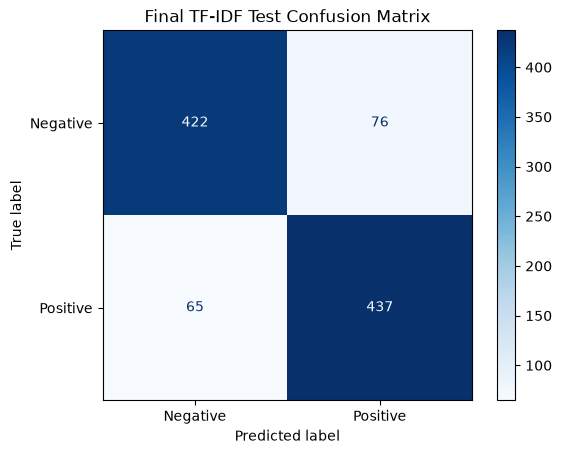

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

confusion = confusion_matrix(test_df["label"], test_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["Negative", "Positive"],
).plot(cmap="Blues")

plt.title("Final TF-IDF Test Confusion Matrix")
plt.show()

<h3 style="color:#009E73;">Comparison with Week 7</h3>

The final Day 2 TF-IDF result is compared with the models evaluated during Week 7 on the same IMDB experiment.

In [13]:
week7_comparison_df = pd.DataFrame([
    {"Model": "Text LSTM", "Test F1": 0.7950},
    {"Model": "Pretrained DistilBERT", "Test F1": 0.8152},
    {"Model": "Week 7 TF-IDF + Logistic Regression", "Test F1": 0.8617},
    {"Model": "Final Weighted Ensemble", "Test F1": 0.8939},
    {
        "Model": "Week 8 Tuned TF-IDF + Logistic Regression",
        "Test F1": test_results_df.loc[0, "F1"],
    },
]).sort_values("Test F1", ascending=False)

display(week7_comparison_df.round(4))

,Model,Test F1
3,Final Weighted Ensemble,0.8939
2,Week 7 TF-IDF + Logistic Regression,0.8617
4,Week 8 Tuned TF-IDF + Logistic Regression,0.8611
1,Pretrained DistilBERT,0.8152
0,Text LSTM,0.7950


<h2 style="color:#0072B2;">2.8 Word Embeddings</h2>

TF-IDF represents a review using vocabulary-based importance scores. Word embeddings instead represent every word as a short dense vector.

Words used in similar contexts receive nearby vectors. Therefore, words such as `good`, `great`, and `excellent` should have similar representations.

Unlike the sparse TF-IDF vector, an embedding vector contains mostly non-zero values.

<h3 style="color:#009E73;">Word2Vec: CBOW and Skip-gram</h3>

Word2Vec learns word vectors from surrounding words.

- CBOW predicts a missing word from its surrounding context.
- Skip-gram predicts surrounding words from one target word.

CBOW is generally faster, while Skip-gram often learns better representations for less frequent words.

<h3 style="color:#009E73;">GloVe and Pretrained Embeddings</h3>

GloVe learns word relationships from global word co-occurrence statistics. Instead of training embeddings only on the small IMDB sample, pretrained embeddings transfer knowledge learned from a much larger text collection.

This experiment uses pretrained 100-dimensional GloVe vectors.

In [14]:
%pip install -q gensim

Note: you may need to restart the kernel to use updated packages.


<h3 style="color:#009E73;">Loading Pretrained GloVe</h3>

The pretrained model maps each known word to a dense vector containing 100 numeric values.

In [15]:
import gensim.downloader as api

glove_model = api.load("glove-wiki-gigaword-100")

print("Vocabulary size:", len(glove_model))
print("Vector dimensions:", glove_model.vector_size)

Vocabulary size: 400000
Vector dimensions: 100


<h3 style="color:#009E73;">Inspecting a Word Vector</h3>

The values inside an embedding dimension do not usually have a direct human-readable meaning. The meaning appears through the position of the complete vector relative to other word vectors.

In [16]:
word = "excellent"
word_vector = glove_model[word]

print("Word:", word)
print("Vector shape:", word_vector.shape)
print("First 10 values:")
print(word_vector[:10])

Word: excellent
Vector shape: (100,)
First 10 values:
[-0.2816    0.18427  -0.06755   0.27694  -0.066775 -0.41389   0.30757
 -0.11097  -0.84585  -0.17047 ]


<h3 style="color:#009E73;">Out-of-Vocabulary Words</h3>

An out-of-vocabulary word is a word that does not exist in the pretrained embedding vocabulary. Such words do not have a stored vector and require a fallback strategy.

In [17]:
words_to_check = [
    "good",
    "excellent",
    "terrible",
    "cinematography",
    "unforgettable",
    "zzzxxyy",
]

oov_check = pd.DataFrame({
    "Word": words_to_check,
    "Found in GloVe": [
        word in glove_model.key_to_index
        for word in words_to_check
    ],
})

display(oov_check)

,Word,Found in GloVe
0,good,True
1,excellent,True
2,terrible,True
3,cinematography,True
4,unforgettable,True
5,zzzxxyy,False


<h2 style="color:#0072B2;">2.9 Cosine Similarity</h2>

Cosine similarity measures the angle between two embedding vectors:

$$
\text{Cosine Similarity}(A,B)
=
\frac{A \cdot B}{\|A\|\|B\|}
$$

A value closer to 1 indicates similar vector directions. A value closer to 0 indicates weak similarity.

In [18]:
word_pairs = [
    ("good", "great"),
    ("good", "excellent"),
    ("bad", "terrible"),
    ("good", "terrible"),
    ("movie", "film"),
]

similarity_results = pd.DataFrame([
    {
        "Word 1": word_1,
        "Word 2": word_2,
        "Cosine similarity": glove_model.similarity(word_1, word_2),
    }
    for word_1, word_2 in word_pairs
])

display(similarity_results.round(4))

,Word 1,Word 2,Cosine similarity
0,good,great,0.7593
1,good,excellent,0.7936
2,bad,terrible,0.7072
3,good,terrible,0.5365
4,movie,film,0.9055


<h3 style="color:#009E73;">Nearest Words in the Embedding Space</h3>

The nearest neighbors of a word are the vocabulary terms with the highest cosine similarity to its vector. This demonstrates the semantic geometry learned from the large pretraining corpus.

In [19]:
query_words = ["good", "terrible", "movie"]
nearest_rows = []

for query_word in query_words:
    for neighbor, similarity in glove_model.most_similar(query_word, topn=5):
        nearest_rows.append({
            "Query word": query_word,
            "Nearest word": neighbor,
            "Similarity": similarity,
        })

nearest_words_df = pd.DataFrame(nearest_rows)
display(nearest_words_df.round(4))

,Query word,Nearest word,Similarity
0,good,better,0.8932
1,good,sure,0.8315
2,good,really,0.8298
3,good,kind,0.8288
4,good,very,0.8261
5,terrible,horrible,0.9195
6,terrible,awful,0.8742
7,terrible,dreadful,0.7822
8,terrible,horrendous,0.7782
9,terrible,horrific,0.7644


<h3 style="color:#009E73;">OOV Handling</h3>

GloVe cannot directly represent a word that is absent from its fixed vocabulary. When a full review is converted into one vector, OOV words are skipped. If no word from a review exists in GloVe, the review receives a zero vector.

<h2 style="color:#0072B2;">2.10 Converting a Review into One Vector</h2>

Each word has a 100-dimensional vector, but Logistic Regression requires one fixed-size vector for the complete review. A simple solution is mean pooling:

$$
\text{Review Vector}
=
\frac{1}{m}
\sum_{i=1}^{m}\mathbf{w}_i
$$

OOV words are skipped. Averaging produces one dense 100-dimensional vector, but it loses word order.

In [20]:
import re
import numpy as np


def review_to_embedding(text):
    tokens = re.findall(r"[a-z]+", str(text).lower())
    known_vectors = [
        glove_model[token]
        for token in tokens
        if token in glove_model.key_to_index
    ]

    if not known_vectors:
        return np.zeros(glove_model.vector_size)

    return np.mean(known_vectors, axis=0)

<h3 style="color:#009E73;">Building the Review Matrices</h3>

The training and validation reviews are converted independently using the fixed pretrained GloVe vectors. No vocabulary is learned from validation data.

In [21]:
X_train_glove = np.vstack(
    train_df["minimal_text"].map(review_to_embedding)
)

X_validation_glove = np.vstack(
    validation_df["minimal_text"].map(review_to_embedding)
)

print("Training shape:", X_train_glove.shape)
print("Validation shape:", X_validation_glove.shape)
print("Matrix type: Dense")

Training shape: (4000, 100)
Validation shape: (1000, 100)
Matrix type: Dense


<h3 style="color:#009E73;">GloVe Validation Baseline</h3>

The same Logistic Regression classifier is trained on the averaged review embeddings. Validation F1 allows a fair representation comparison with TF-IDF.

In [22]:
glove_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

glove_classifier.fit(
    X_train_glove,
    train_df["label"],
)

glove_validation_predictions = glove_classifier.predict(
    X_validation_glove
)

glove_validation_f1 = f1_score(
    validation_df["label"],
    glove_validation_predictions,
)

print("GloVe validation F1:", round(glove_validation_f1, 4))
print("TF-IDF validation F1:", round(best_validation_f1, 4))

GloVe validation F1: 0.7972
TF-IDF validation F1: 0.8808


<h2 style="color:#0072B2;">2.11 TF-IDF, GloVe, and BERT</h2>

| Representation | Main information | Vector type | Main limitation |
|---|---|---|---|
| TF-IDF | Word and phrase importance | Sparse review vector | Does not understand semantic meaning |
| GloVe | General semantic relationships | Dense fixed word vectors | One fixed vector per word |
| BERT | Meaning based on the current sentence | Dense contextual vectors | More computationally expensive |

GloVe and Word2Vec assign one fixed vector to each word. BERT produces a different representation depending on the surrounding context.

<h2 style="color:#0072B2;">2.12 Final GloVe Test Evaluation</h2>

The GloVe method and classifier have been fixed using training and validation data. The test reviews are now converted into averaged embedding vectors and evaluated once.

In [23]:
X_test_glove = np.vstack(
    test_df["minimal_text"].map(review_to_embedding)
)

glove_test_predictions = glove_classifier.predict(X_test_glove)
glove_test_probabilities = glove_classifier.predict_proba(X_test_glove)[:, 1]

glove_test_results_df = pd.DataFrame([{
    "Model": "Averaged GloVe + Logistic Regression",
    "Accuracy": accuracy_score(test_df["label"], glove_test_predictions),
    "Precision": precision_score(test_df["label"], glove_test_predictions),
    "Recall": recall_score(test_df["label"], glove_test_predictions),
    "F1": f1_score(test_df["label"], glove_test_predictions),
    "ROC-AUC": roc_auc_score(test_df["label"], glove_test_probabilities),
}])

display(glove_test_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Averaged GloVe + Logistic Regression,0.786,0.7975,0.7689,0.783,0.8645


<h3 style="color:#009E73;">Final Representation Comparison</h3>

TF-IDF and averaged GloVe are compared using the same training, validation, and test splits. This isolates the effect of the text representation.

In [24]:
representation_comparison_df = pd.DataFrame([
    {
        "Representation": "Tuned TF-IDF",
        "Validation F1": best_validation_f1,
        "Test F1": test_results_df.loc[0, "F1"],
    },
    {
        "Representation": "Averaged pretrained GloVe",
        "Validation F1": glove_validation_f1,
        "Test F1": glove_test_results_df.loc[0, "F1"],
    },
])

representation_comparison_df = representation_comparison_df.sort_values(
    "Test F1",
    ascending=False,
).reset_index(drop=True)

display(representation_comparison_df.round(4))

,Representation,Validation F1,Test F1
0,Tuned TF-IDF,0.8808,0.8611
1,Averaged pretrained GloVe,0.7972,0.7830


<h3 style="color:#009E73;">Visual Comparison</h3>

The chart compares validation and test F1 for the two numerical text representations.

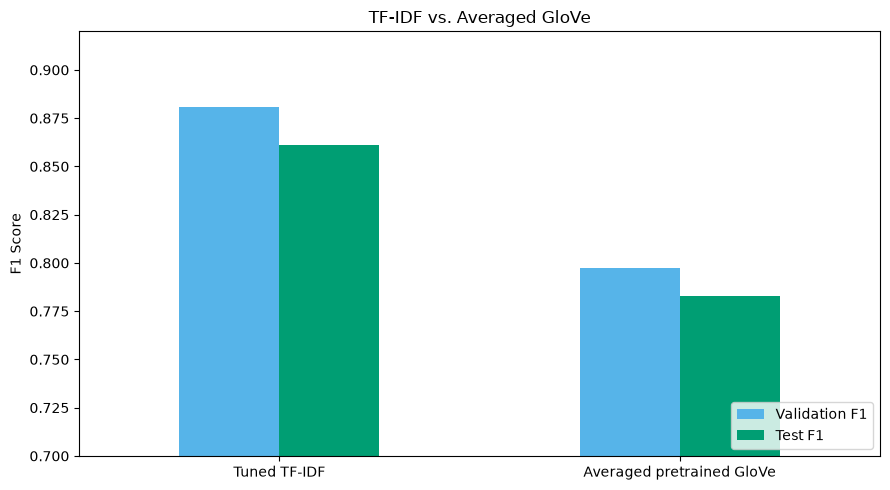

In [25]:
plot_data = representation_comparison_df.set_index("Representation")

plot_data[["Validation F1", "Test F1"]].plot(
    kind="bar",
    figsize=(9, 5),
    color=["#56B4E9", "#009E73"],
)

plt.ylim(0.70, 0.92)
plt.title("TF-IDF vs. Averaged GloVe")
plt.ylabel("F1 Score")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">2.13 Saving Day 2 Results</h2>

The main validation experiments, test metrics, representation comparison, and interpretable TF-IDF terms are saved for later integration and reporting.

In [26]:
day2_output_directory = Path("outputs/week8_day2")
day2_output_directory.mkdir(parents=True, exist_ok=True)

validation_results_df.to_csv(
    day2_output_directory / "tfidf_validation_experiments.csv",
    index=False,
)

pd.concat([
    test_results_df,
    glove_test_results_df,
], ignore_index=True).to_csv(
    day2_output_directory / "representation_test_metrics.csv",
    index=False,
)

representation_comparison_df.to_csv(
    day2_output_directory / "representation_f1_comparison.csv",
    index=False,
)

negative_terms_df.to_csv(
    day2_output_directory / "strongest_negative_terms.csv",
    index=False,
)

positive_terms_df.to_csv(
    day2_output_directory / "strongest_positive_terms.csv",
    index=False,
)

print("Day 2 results saved to:", day2_output_directory)

Day 2 results saved to: outputs/week8_day2


<h2 style="color:#0072B2;">Day 2 Conclusion</h2>

Day 2 converted the cleaned IMDB reviews into two numerical representations and compared them on the same experiment splits.

### Main Results

- The best TF-IDF configuration used `minimal_text`, unigrams and bigrams, 10,000 features, and sublinear term frequency.
- Tuned TF-IDF achieved validation F1 `0.8808` and test F1 `0.8611`.
- Averaged pretrained GloVe achieved validation F1 `0.7972` and test F1 `0.7830`.
- The Week 7 weighted ensemble remained the strongest overall model with test F1 `0.8939`.

### Final Decision

TF-IDF is the better standalone representation for this IMDB experiment. It learns task-specific word and bigram importance directly from the sentiment data. GloVe captures useful semantic relationships, but simple mean pooling loses word order and dilutes important sentiment signals. BERT contextual embeddings address several limitations of fixed embeddings by changing each word representation according to its sentence context.